# 모델 학습 결과서

### 1️⃣ **고객 이탈률 예측 모델의 핵심 평가지표**

**1. ROC 곡선 및 AUC (Area Under the Curve)**
|구분|내용|
|:-|:-|
|**정의**|- ROC 곡선: False Positive Rate와 True Positive Rate의 관계를 나타내는 곡선<br>- AUC: ROC 곡선 아래 면적 (0~1 범위)|
|**해석 기준**|- AUC = 0.5: 무작위 예측과 동일한 성능<br>- AUC = 1.0: 완벽한 분류 성능<br>- AUC ≥ 0.8: 우수한 모델로 평가|
|**활용 목적**|- 임계값에 관계없는 전반적 성능 평가<br>- 클래스 불균형 상황에서의 안정적인 성능 측정<br>- 모델 간 객관적 성능 비교|

**2. Recall (재현율, 민감도)**
|구분|내용|
|:-|:-|
|**정의**|- 공식: Recall = TP / (TP + FN)<br>- 실제 이탈 고객 중 올바르게 예측한 비율|
|**해석 기준**|- Recall = 0.8: 실제 이탈하는 고객 10명 중 8명을 정확히 예측<br>- False Negative(이탈 고객 놓침) 최소화에 중점|
|**활용 목적**|- 이탈 고객 사전 파악을 통한 retention 전략 수립<br>- 놓친 이탈 고객으로 인한 직접적 매출 손실 방지<br>- 이탈 예방 비용이 신규 고객 획득 비용보다 효율적|

**3. Accuracy (정확도)**
|구분|내용|
|:-|:-|
|**정의**|- 공식: Accuracy = (TP + TN) / (TP + TN + FP + FN)<br>- 전체 예측 중 올바른 예측의 비율율|
|**해석 기준**|- Accuracy = 0.85: 전체 예측의 85%가 정확<br>- 모델의 전반적 성능을 나타내는 직관적 지표|
|**활용 목적**|- 모델의 기본적인 예측 능력 평가<br>- 이해관계자와의 커뮤니케이션용 지표<br>- 이탈/비이탈 양쪽을 고려한 종합 성능 평가|

### 2️⃣ **모델 성능 비교 및 최적화 전략**

##### **■ 5개 모델 성능 비교**

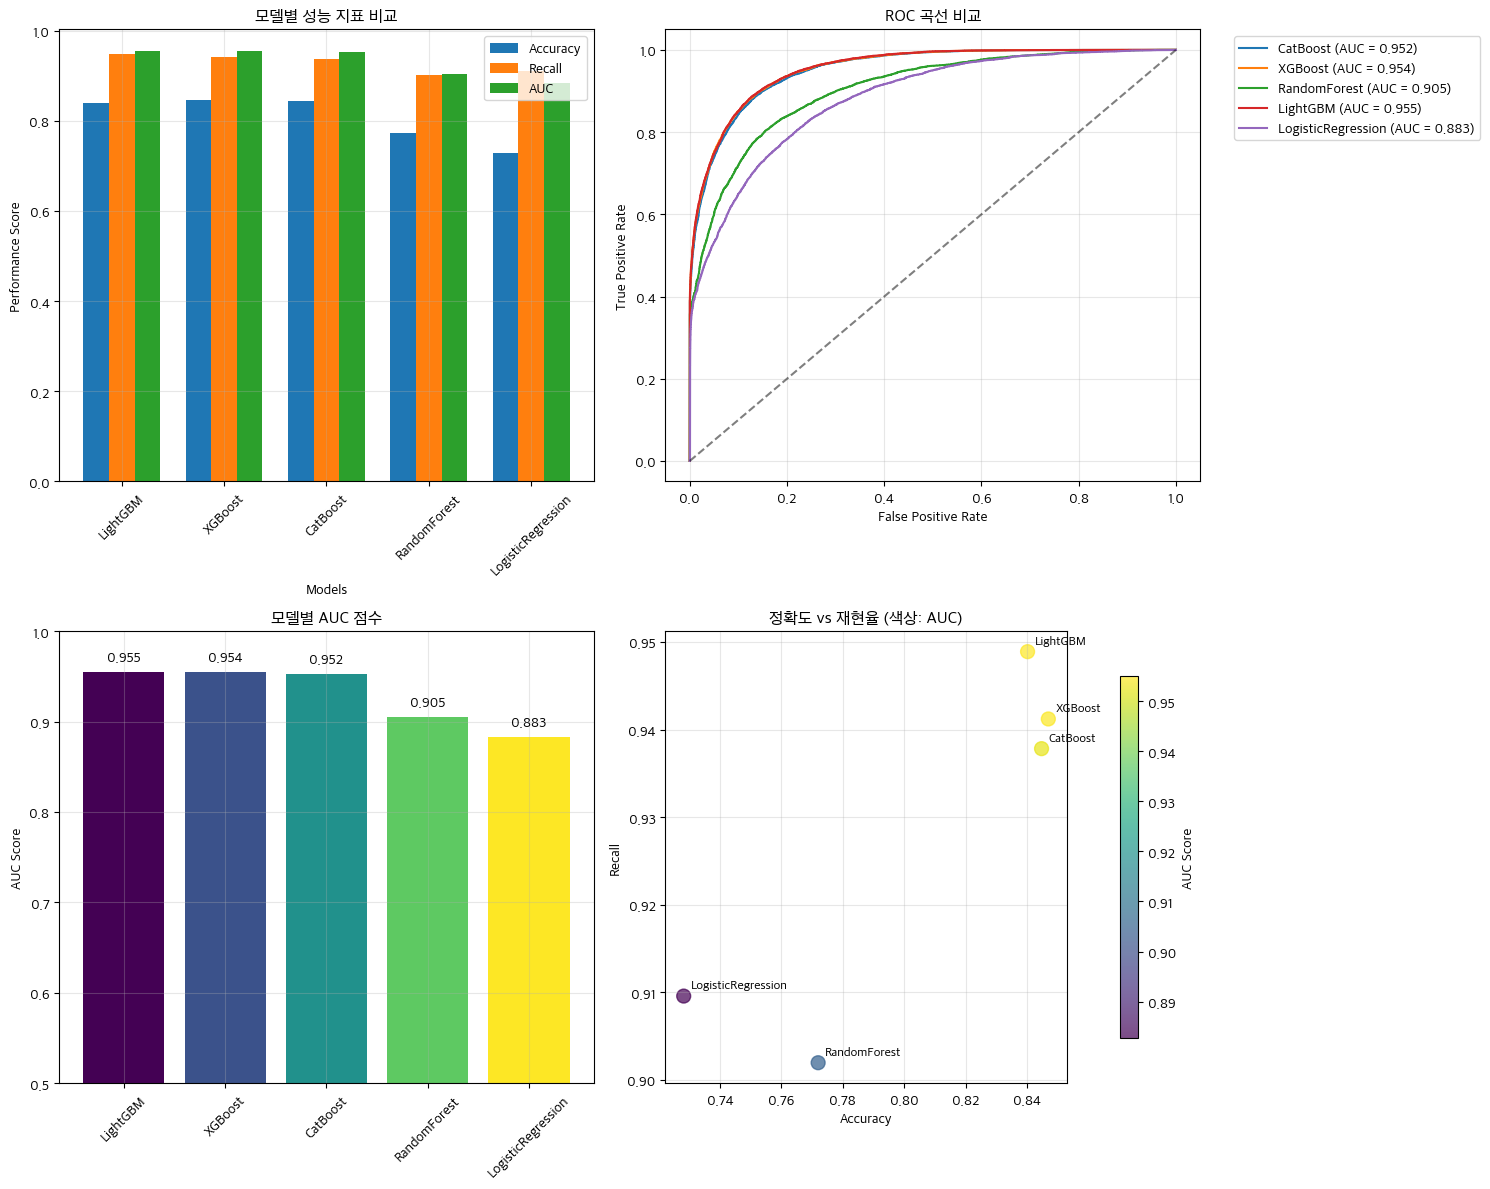

##### **■ 최종 선정 모델**
🚀 **LightGBM** 🚀
- AUC: 0.9549
- Accuracy: 0.8401
- Recall: 0.9489

##### **■ 최적화 목표**
**Recall 최적화**
- 목표: 이탈 고객을 최대한 많이 사전 파악
- 비즈니스 근거: 놓친 이탈 고객으로 인한 직접적 매출 손실 최소화
- 전략: False Negative를 줄이는 방향으로 모델 튜닝

**임계값 최적화**
- 기본 임계값(0.5) 대신 Recall 최대화 임계값 탐색
- ROC 곡선에서 최적 임계값 선정
- 비즈니스 제약사항(예: 마케팅 예산, 인력 등) 고려


### 3️⃣ **하이퍼파라미터 튜닝**

##### **■ 튜닝 (Optuna 활용)**

**Optuna 개념**
- 자동 하이퍼파라미터 최적화 프레임워크
- 베이지안 최적화 기반의 효율적인 탐색 알고리즘
- Tree-structured Parzen Estimator (TPE) 샘플링 사용

**주요 장점**
- 효율적 탐색: 랜덤 서치 대비 빠른 최적해 발견
- 유연성: 다양한 ML 라이브러리와 호환
- 조기 종료: 성능이 낮은 시도를 자동으로 중단
- 시각화: 최적화 과정과 결과를 직관적으로 확인 가능

**튜닝 방식**
- Optuna의 Scoring 기준을 바꿔가며 최적화 시도
- 세 평가지표가 최대한 모두 개선되는 Scoring으로 최종 선택


##### **■ 튜닝 결과**
- Scoring = **Recall**

![parameter_tuning_result(Recall).png](attachment:parameter_tuning_result(Recall).png)

- Scoring = **ROC_AUC**

![parameter_tuning_result(ROC_AUC).png](attachment:parameter_tuning_result(ROC_AUC).png)


- Scoring = **Accuracy**

![parameter_tuning_result(Accuracy).png](attachment:parameter_tuning_result(Accuracy).png)

### 4️⃣ **최종 모델 성능**

**평가 지표**
|지표|결과|
|:-|:-|
|AUC-ROC|0.9606|
|Recall|0.8706|
|F1-Score|0.8577|
|Accuracy|0.8930|

**하이퍼파라미터**
|하이퍼파라미터|값|
|:-|:-|
|num_leaves|93|
|max_depth|12|
|learning_rate|0.1585602142357632|
|n_estimators|775|
|min_child_samples|21|
|subsample|0.6460381634191902|
|colsample_bytree|0.9200747984283645|
|reg_alpha|0.5913198784359284|
|reg_lambda|1.804551464720626|